# Exercise 4

This exercise is based on Chapter 14 and the beginning of Chaprt 15 of "Computational and Inferential Thinking: The Foundations of Data Science."

The material can be found in Jupyter notebooks in GSP538/ds_book/chapters/15/ and GSP538/ds_book/chapters/15/.

#### Answer the following written questions

There is a blank Markdown cell after each question for your answer (double click in the blank cell to type your answer). Be sure to run your Markdown cells to format your answers.

1. Why are means sensitive to outliers, but medians are not?

The mean is calculated by summing all values and dividing by the number of values. A single extreme outlier changes the sum dramatically, which shifts the mean toward the outlier. The median, on the other hand, is simply the middle value when the data are sorted. Moving an extreme value even further from the center does not change which value sits in the middle position. In other words, the median depends only on the rank-order of the data, not on the magnitude of individual values, so outliers have little or no effect on it.

2. When will the mean and median be almost equal? 

The mean and median will be almost equal when the distribution is roughly symmetric — that is, when the data are evenly spread on both sides of the center without a long tail in either direction. In a symmetric distribution, there are no extreme outliers pulling the mean away from the center, so the balance point (mean) and the middle value (median) coincide.

3. In a $2x2$ correlation matrix, the numbers in the upper-left and lower-right will be identical; the numbers in the lower-left and upper-right will also be identical. Why is this and what are the possible values for each pair?

A correlation matrix reports the correlation coefficient ($r$) between every pair of variables. The upper-left and lower-right entries are the correlation of each variable with itself, which is always **1.0** (a variable is perfectly linearly related to itself). The lower-left and upper-right entries are the correlation between the two different variables. Because $r$ is symmetric — the correlation of $X$ with $Y$ is the same as the correlation of $Y$ with $X$ — these two off-diagonal values are always identical. So the diagonal values are always 1.0, and the two off-diagonal values are the same number, which can range from −1 to +1.

4. The book talks about sampling with-replacement and without-replacement. What is the difference between these two methods? When you are sampling from a very large pool, why does it not matter much if you use the with-replacement or without-replacement approach?

**Sampling with replacement** means that after an item is selected from the population, it is "put back" so it can potentially be selected again. **Sampling without replacement** means that once an item is selected, it is removed from the pool and cannot be chosen again.

When sampling from a very large population, the chance of selecting the same item twice is extremely small, so removing an item (without replacement) barely changes the composition of the remaining pool. The probabilities on each draw are nearly identical whether or not the item is returned. Therefore, in practice, with-replacement and without-replacement sampling give virtually the same results when the population is much larger than the sample.

5. The book mentions that ecological correlations can be problematic. In your own words, what should we be concerned about? (Hint: you might want to read about "ecological fallacy" to get more background on this.)

Ecological correlations are correlations computed on data that have been aggregated into groups (e.g., state averages or county means) rather than on individual observations. The concern is the **ecological fallacy**: conclusions drawn from aggregated data may not apply to individuals. Averaging smooths out individual variation, which tends to inflate the correlation — group-level $r$ values are typically much larger in magnitude than individual-level $r$ values. This can lead us to believe a relationship between two variables is much stronger than it actually is, or to attribute a group-level pattern to individual behavior when it may not hold at that level.

6. The book discussed medians, percentiles and the spread of data. A common way of combining and representing those concepts is the "inter quartile range" (IQR) and the "box plot." Read the following webpage https://discovery.cs.illinois.edu/learn/Exploratory-Data-Analysis/Quartiles-and-Box-Plots/ on these topics (feel free to read more if this page is not clear). 
    - How many data points are inside the "box" of any box plot?
    - What is the criteria used to define an outlier using a box plot?

- **How many data points are inside the "box"?** The box spans from the first quartile (Q1, 25th percentile) to the third quartile (Q3, 75th percentile), so it contains the middle **50%** of the data points.
- **Outlier criteria:** A data point is considered an outlier if it falls more than **1.5 × IQR** below Q1 or above Q3, where IQR = Q3 − Q1 (the interquartile range). That is, any value below $Q1 - 1.5 \times IQR$ or above $Q3 + 1.5 \times IQR$ is flagged as an outlier.

7. Standard deviation and variance both measure the spread of a dataset. 
    - Why is the standard deviation easier to interpret than the variance?
    - How do you convert between standard deviation and variance?

- **Why is standard deviation easier to interpret?** The variance is the mean of squared deviations, so its units are the square of the original units (e.g., feet²). The standard deviation is the square root of the variance, which brings it back to the same units as the original data (e.g., feet). This makes it directly interpretable as a "typical distance from the mean."
- **Converting between them:** Variance = (Standard Deviation)². Standard Deviation = $\sqrt{\text{Variance}}$.

8. Approximately how much area is under the standard normal curve between $\pm 1$ standard deviation of the mean? Between $\pm 2$ standard deviations?

For a standard normal distribution, approximately **68%** of the area falls within $\pm 1$ standard deviation of the mean, and approximately **95%** of the area falls within $\pm 2$ standard deviations of the mean.

9. The strength of the central limit theorem is that the distribution of the sample mean is approximately normal.
    - What is a sample mean?
    - Does the distribution of the source data need to be approximately normal for the distribution of the sample mean to be approximately normal?

- **What is a sample mean?** A sample mean is the average of the values in a randomly drawn sample from a population. It is typically used as an estimate of the true population mean.
- **Does the source data need to be approximately normal?** No — that is precisely the power of the Central Limit Theorem. Regardless of the shape of the original population distribution (skewed, uniform, bimodal, etc.), the distribution of the sample mean will approach a normal distribution as the sample size $n$ grows large enough.

#### The following questions require you to run Python code.

For these questions, you will be using data on the specific trees sampled in Arizona from the US Forest Service Forest Inventory and Analysis (FIA) National Program.

> FIA reports on status and trends in forest area and location; in the species, size, and health of trees; in total tree growth, mortality, and removals by harvest; in wood production and utilization rates by various products; and in forest land ownership.

https://www.kaggle.com/datasets/usforestservice/usfs-fia

Run the following cell to import the data.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

trees = pd.read_csv('data/usfs_az_plot_tree.csv')
trees = trees.loc[trees.measurement_year>=2001,]

This exercise includes hints and notes, but there is also an assumption that you can apply stuff learned in the previous exercises. 

Hints:
- You need to insert cells to answer questions.
- If a cell seems to be taking too long to run, you can click the "Interrupt" button in the small toolbar at the top of the notebook. Sometimes it takes a moment for the cell to actually stop.
- If you have been testing a lot of things, it is sometimes good to restart the kernel ("Kernel" button in the toolbar). Restarting the kernel gives the notebook a fresh start by removing all the packages, variables and datasets from memory; it does not remove the code you have typed. You then rerun the cells you want to keep.
- Please remove any unnecessary cells and code before submitting your completed notebook.

10. Run the following cell.
    - How do the rows of this output relate to a box plot? How do they not relate?
    - Which two columns should not have been included in this output? Why?
    - Pick one column and interpret the results. (Note: Do not just say, "The mean is ___, the standard deviation is ___, ...". Think about the general definition of each statistic, then look at the particular values for your chosen column; pay attention to how the values relate to one another; then create a narrative response that reveals insight about the distribution of the data.)

In [2]:
trees.describe().round(2)

,unique_tree,total_height,current_diameter,total_age,compacted_crown_ratio,trees_per_acre_unadjusted,measurement_year,plot_county_code,elevation
count,1.124060e+05,112406.00,112406.00,20120.00,97520.00,110766.00,112406.00,112406.00,112406.00
mean,1.866414e+16,24.08,9.54,108.12,59.44,12.10,2009.33,9.02,6489.65
std,4.269024e+16,17.57,5.17,72.20,22.10,19.56,5.13,7.17,1229.09
min,2.222940e+14,1.00,1.00,1.00,0.00,6.02,2001.00,1.00,300.00
25%,1.168985e+15,13.00,6.10,58.00,45.00,6.02,2005.00,5.00,5800.00
50%,4.038236e+15,18.00,8.30,92.00,60.00,6.02,2009.00,7.00,6530.00
75%,1.887783e+16,29.00,11.90,140.00,75.00,6.02,2014.00,15.00,7190.00
max,1.887821e+17,149.00,53.50,989.00,99.00,74.97,2018.00,27.00,10570.00


**How the rows relate to a box plot:**
The `describe()` output includes the min, 25th percentile (Q1), 50th percentile (median), 75th percentile (Q3), and max — which are exactly the five-number summary used to construct a box plot. The "box" of a box plot spans from Q1 to Q3 with a line at the median, and the whiskers extend toward the min and max.

**How they do not relate:**
The `describe()` output also includes count, mean, and standard deviation, which are not part of a box plot. Additionally, a true box plot clips its whiskers at 1.5 × IQR from Q1/Q3 and plots more extreme values individually as outliers, whereas `describe()` simply reports the overall min and max without identifying outliers.

**Which two columns should not have been included?**
`unique_tree` and `plot_county_code` should not have been included. `unique_tree` is an identifier (not a measured quantity), so computing its mean or standard deviation is meaningless. Similarly, `plot_county_code` is a categorical code (a FIPS county number), not a continuous measurement — its summary statistics have no meaningful interpretation.

**Interpretation of `total_age`:**
There are only 20,120 non-null `total_age` values (compared to 112,406 total rows), so age was recorded for roughly 18% of the trees. Among those, the mean age is about 108 years with a standard deviation of 72 years, indicating a very wide spread — ages vary considerably. The median is 92 years, which is noticeably lower than the mean of 108 years. This tells us the distribution is right-skewed: most trees are younger, but a long tail of very old trees pulls the mean up. The youngest tree is 1 year old and the oldest is 989 years old — an extraordinary outlier. The IQR spans from 58 years (Q1) to 140 years (Q3), so the middle 50% of trees are between roughly 58 and 140 years old, an 82-year range. The max of 989 years is far above Q3 + 1.5 × IQR (= 140 + 123 = 263), confirming that there are significant outliers on the upper end.

11. Boxplots and outliers.
    - Create a boxplot for `total_age` using Pandas or Seaborn for just the 2010 trees. (Note: you have not seen an example in the book for creating box plots, but the syntax is similar to what you have seen for other plots.)
    - Create a separate boxplot for `elevation` using Pandas or Seaborn for just the 2010 trees.
    - Interpret the two box plots, be sure to include a discussion of outliers.

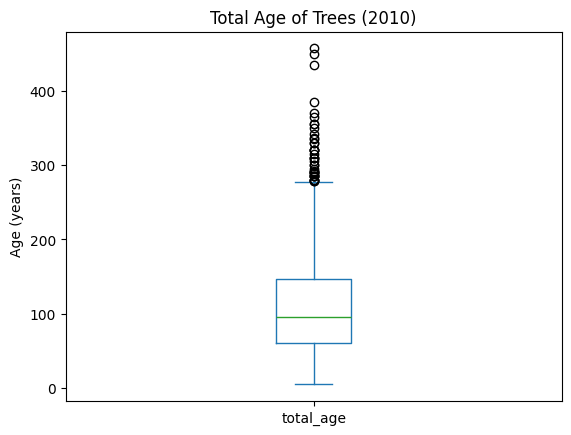

In [3]:
trees_2010 = trees[trees.measurement_year == 2010]
trees_2010['total_age'].plot.box()
plt.title('Total Age of Trees (2010)')
plt.ylabel('Age (years)')
plt.show()

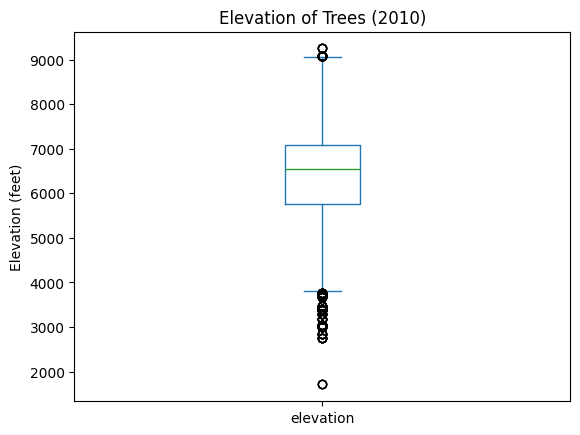

In [4]:
trees_2010['elevation'].plot.box()
plt.title('Elevation of Trees (2010)')
plt.ylabel('Elevation (feet)')
plt.show()

**Total Age boxplot:** The box (IQR) spans from roughly 60 to 145 years, with the median around 95 years. The lower whisker extends down to about 5 years while the upper whisker reaches approximately 275 years. There are many outliers above the upper whisker, with individual trees aged up to about 460 years. This shows a strongly right-skewed distribution — most trees are relatively young, but a substantial number of very old trees exist. The large number of upper outliers suggests that while half the aged trees are under ~95 years, a long tail of ancient trees is common in Arizona forests.

**Elevation boxplot:** The box spans roughly 5,800 to 7,100 feet with a median near 6,500 feet. The lower whisker extends down to about 4,000 feet and the upper whisker reaches about 9,000 feet. There are outliers on both ends — a cluster of low-elevation outliers below about 3,800 feet and a few high-elevation outliers above 9,000 feet, plus a single very low outlier near 1,800 feet. This indicates that most sampled trees in Arizona are at mid-to-high elevations (forested mountain areas), with a few trees sampled at unusually low or high elevations. Compared to the age plot, the elevation distribution is more symmetric, though the lower outliers suggest a handful of plots in desert lowlands.

12. Correlation.
    - Create a 4x4 correlation matrix for `total_height`, `current_diameter`, `compacted_crown_ratio` and `elevation`.
    - Pick three values in the table to highlight the relationships between the variables. (Note: This should not simply repeat the numbers in the table. It should demonstrate that you understand how to interpret the magnitudes and signs of correlation values.)

In [5]:
trees[['total_height', 'current_diameter', 'compacted_crown_ratio', 'elevation']].corr().round(3)

,total_height,current_diameter,compacted_crown_ratio,elevation
total_height,1.000,0.388,-0.362,0.465
current_diameter,0.388,1.000,0.038,-0.008
compacted_crown_ratio,-0.362,0.038,1.000,-0.245
elevation,0.465,-0.008,-0.245,1.000


Three notable relationships:

1. **`total_height` and `elevation` ($r = 0.465$):** This is the strongest correlation in the matrix. It is positive and moderate, meaning trees at higher elevations tend to be taller. This makes sense because higher elevations in Arizona receive more precipitation, which supports taller tree species like ponderosa pine and Douglas fir, whereas lower elevations have shorter woodland species.

2. **`total_height` and `compacted_crown_ratio` ($r = -0.362$):** This is a moderate negative correlation. As trees grow taller, their crown ratio (the proportion of the tree covered by the live crown) tends to decrease. Taller trees in dense forests lose their lower branches due to shading, leading to smaller crown ratios.

3. **`current_diameter` and `elevation` ($r = -0.008$):** This correlation is essentially zero, indicating no linear relationship between a tree's diameter and the elevation where it grows. This contrasts with the height-elevation relationship and suggests that diameter is more influenced by species, age, and competition than by elevation alone.

13. Compare dead and live trees.
    - Use `groupby` to split the `trees` DataFrame into `Dead tree` and `Live tree` groups, and compute the count, mean and standard deviation for `total_height` and `current_diameter` for each group. (Note: the resulting DataFrame will have 12 values: 2 tree statuses x 2 variables x 3 statistics. Hint: this can be done as a single command.)
    - Compare dead and live trees based on this table.

In [6]:
trees.groupby('tree_status_code_name')[['total_height', 'current_diameter']].agg(['count', 'mean', 'std']).round(2)

total_height               current_diameter            
                             count   mean    std            count  mean   std
tree_status_code_name                                                        
Dead tree                    14886  27.73  19.45            14886  9.64  4.90
Live tree                    97520  23.53  17.20            97520  9.53  5.21

Dead trees have a higher mean `total_height` (27.73 ft) than live trees (23.53 ft), and a wider standard deviation (19.45 vs. 17.20), indicating that the dead trees tend to be taller on average and more variable in height. This could suggest that taller trees are more vulnerable to mortality factors such as drought, fire, or disease. For `current_diameter`, the two groups are very similar — dead trees average 9.64 inches and live trees 9.53 inches, with comparable standard deviations. So diameter does not appear to differ meaningfully between dead and live trees, while height does. There are far more live trees (97,520) than dead trees (14,886), meaning about 13% of the sampled trees are dead.

14. Tree height distribution.
    - Create a histogram of `total_height` using seaborn or pandas; choose a number of bins that you think best represents the distribution (note: do not use the default).
    - Is the distribution approximately normal? Explain.

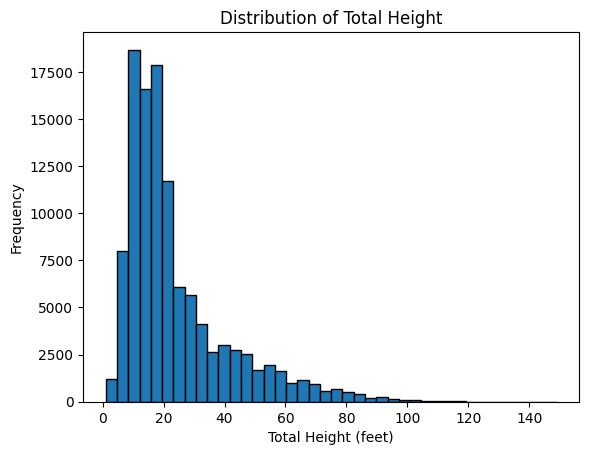

In [7]:
trees['total_height'].plot.hist(bins=40, edgecolor='black')
plt.title('Distribution of Total Height')
plt.xlabel('Total Height (feet)')
plt.ylabel('Frequency')
plt.show()

The distribution of `total_height` is **not approximately normal**. It is clearly right-skewed: the bulk of the data is concentrated at the low end (roughly 5–25 feet), with a long tail stretching out to over 140 feet. A normal distribution would be symmetric and bell-shaped around the mean, but this histogram peaks early and trails off gradually to the right. The skewness is also consistent with the earlier observation that the mean (24 ft) is higher than the median (18 ft), which is a hallmark of a right-skewed distribution.

15. The following cell defines a function called `get_mean_hist`.
    - Explain what the arguments `n`, `draws` and `bins` are doing in the function.
    - Which, if any, of the three must the user include for the function to run?

In [8]:
def get_mean_hist(n, draws, bins=30):
    means = []
    for draw in range(draws):
        mean = trees.sample(n)['total_height'].mean()
        means.append(mean)
    mean_df = pd.DataFrame({'mean_height':means})
    mean_df.hist(bins=bins);

- **`n`**: The number of trees to randomly sample from the `trees` DataFrame in each draw. This is the sample size for each individual sample.
- **`draws`**: The number of times to repeat the sampling process. Each draw takes a random sample of `n` trees, computes the mean `total_height`, and stores it. So `draws` controls how many sample means are collected and ultimately plotted in the histogram.
- **`bins`**: The number of bins (bars) to use in the histogram. It has a default value of 30, so it is optional.

**Which must the user include?** The user must provide `n` and `draws`, because they have no default values. `bins` is optional because it has a default value of 30 — if the user does not specify it, the function will use 30 bins automatically.

16. Central limit theorem (CLT)
    - Choose three combinations of `n` and `draws` and use them to demonstrate how the CLT works. Your answer should contain 3 histograms from `get_mean_hist`. (Note: adjust the `bins` argument if it helps your demonstration of the CLT. Note: the function will take longer to run for larger values of `draws`. Hint: if you are having a hard time getting started on this, first write out the definition of the CLT in your own words.)
    - Explain the CLT and how your choices of `n` and `draws` help demonstrate how the CLT works. Be sure to mention how this relates to the shape of the `total_height` histogram in the earlier question.

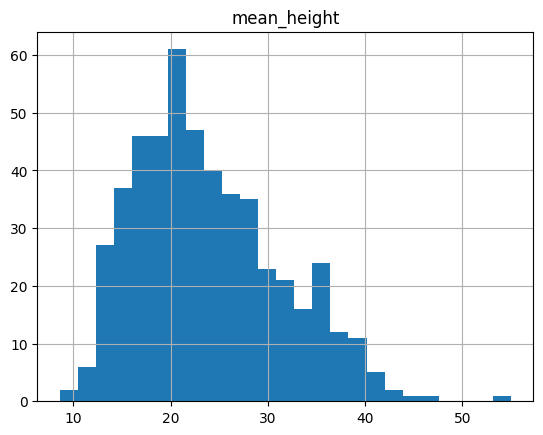

In [9]:
get_mean_hist(n=5, draws=500, bins=25)

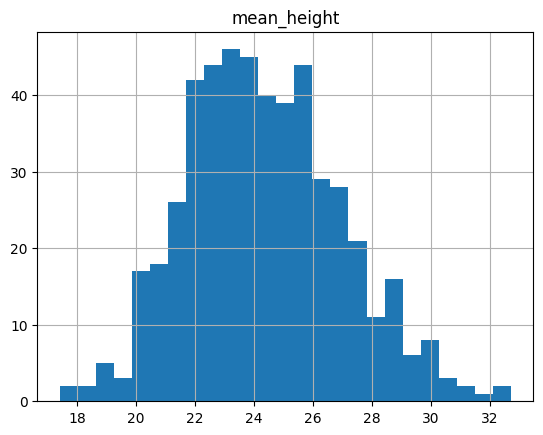

In [10]:
get_mean_hist(n=50, draws=500, bins=25)

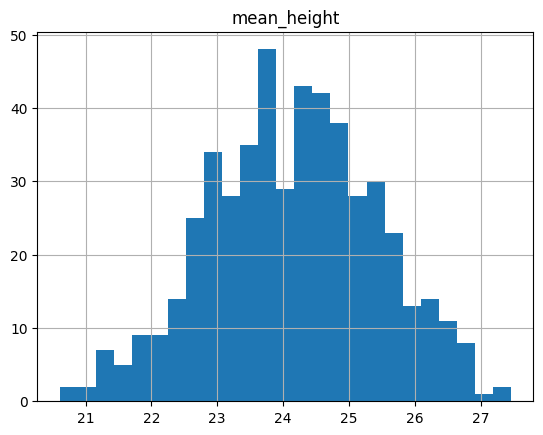

In [11]:
get_mean_hist(n=200, draws=500, bins=25)

The **Central Limit Theorem (CLT)** states that the distribution of sample means will approximate a normal distribution as the sample size increases, regardless of the shape of the original population distribution.

The three histograms above demonstrate this:

- **n=5, draws=500**: With only 5 trees per sample, the distribution of means is wide and somewhat rough. It begins to show a bell shape but still has noticeable irregularity — reflecting the skew seen in the `total_height` histogram from question 14.
- **n=50, draws=500**: With 50 trees per sample, the distribution of means is noticeably tighter and more symmetric, forming a clearer bell curve. The spread has decreased because averaging over more observations reduces variability.
- **n=200, draws=500**: With 200 trees per sample, the distribution is very tightly concentrated around the population mean and is almost perfectly normal.

In each case, `draws=500` means we repeated the sampling process 500 times — giving us 500 sample means to plot. This provides enough repetitions to see the shape of the sampling distribution clearly. The key variable driving the CLT is `n` (sample size): as `n` increases, the sampling distribution becomes more normal and its spread (standard error) decreases. This holds even though the original `total_height` distribution is not perfectly normal — that is the power of the CLT.